In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

import jax
import jax.numpy as jnp
import jax_cosmo as jc

import optax
from flax import nnx
import orbax.checkpoint as ocp

import diffrax
from diffrax import diffeqsolve, ODETerm, Dopri5, LeapfrogMidpoint, PIDController, SaveAt, ConstantStepSize
from jax.experimental.ode import odeint

import jaxpm
from jaxpm.painting import cic_paint, cic_read
from jaxpm.pm import linear_field, lpt, make_ode_fn, pm_forces, make_ode_fn_diffrax, make_ode_fn
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm import camels, plotting, hpm, pm, nn

jax.devices("gpu")

[cuda(id=0)]

In [3]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3

In [4]:
CV = "CV_0"
i_snapshots = range(1, 33+8, 8)

In [5]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None, 0))

# CAMELS nbody

In [6]:
nbody_dict = camels.load_CV_snapshots(
    "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG_DM/CV/" + CV,
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    return_hydro=False
)

cosmo = nbody_dict["cosmo"]
scales = nbody_dict["scales"]

n_dm_poss = nbody_dict["dm_poss"]
n_dm_vels = nbody_dict["dm_vels"]

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG_DM/CV/CV_0/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG_DM/CV/CV_0/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG_DM/CV/CV_0/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG_DM/CV/CV_0/snapshot_074.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG_DM/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)


loading snapshots: 100%|██████████| 5/5 [00:14<00:00,  2.99s/it]


In [7]:
pm_ode = pm.make_ode_fn_diffrax(cosmo, mesh_shape)

res = diffeqsolve(
        terms=ODETerm(pm_ode),
        solver=LeapfrogMidpoint(),
        t0=scales[0],
        t1=scales[-1],
        dt0=0.01,
        y0=jnp.stack([n_dm_poss[0], n_dm_vels[0]]),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)
res = res.ys
res = jnp.transpose(res, (1,0,2,3))

pm_dm_poss, pm_dm_vels = res

100%|██████████| 5/5 [00:06<00:00,  1.32s/it]


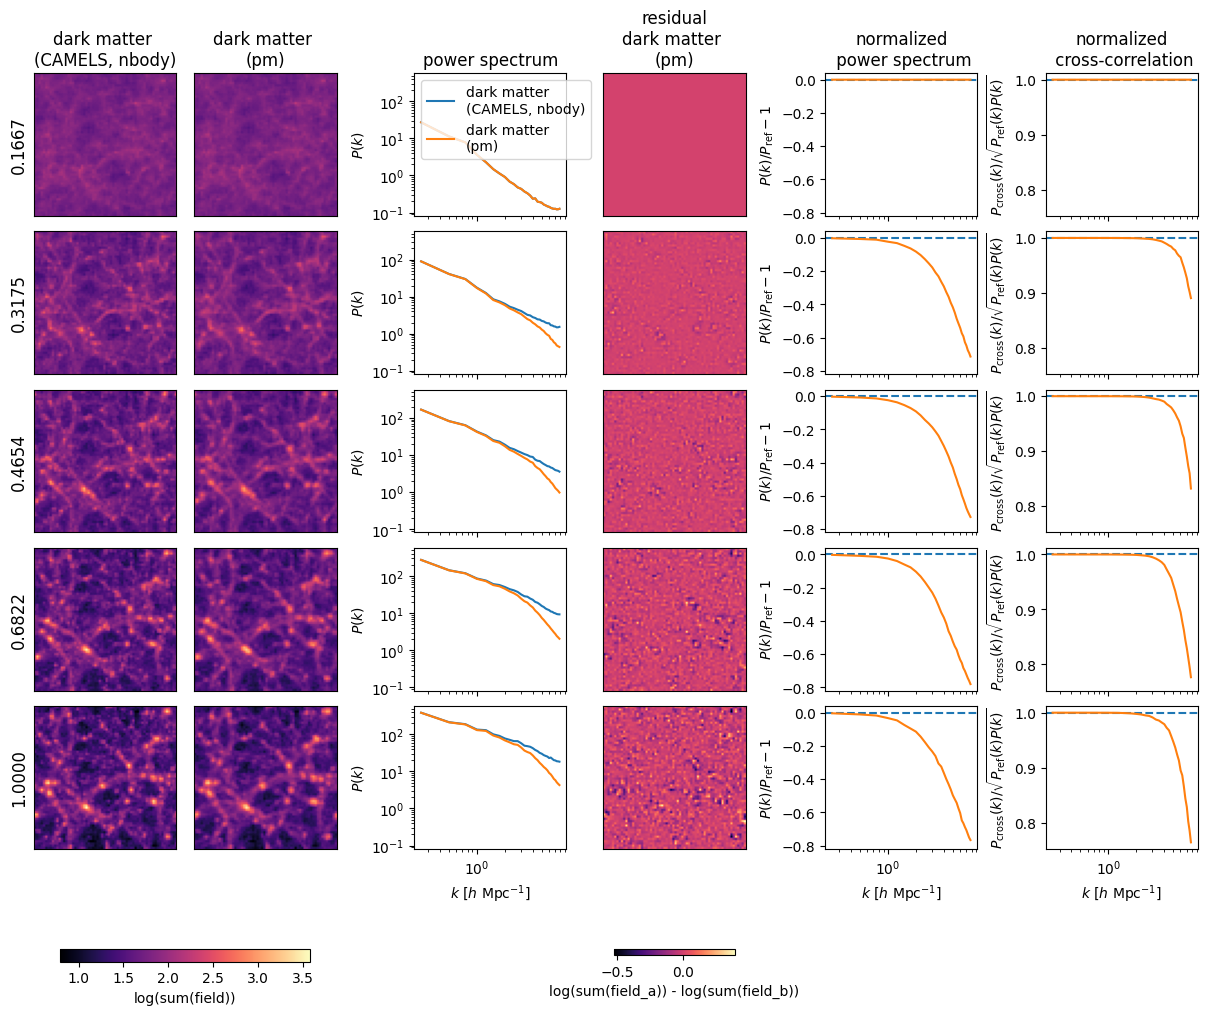

In [8]:
plotting.compare_particle_evolution(
    mesh_shape,
    scales,
    jnp.stack([n_dm_poss, pm_dm_poss], axis=0),
    include_pk=True,
    include_reference=True,
    # values
    shared_colorbar=True,
    # cosmetics
    title=None,
    col_titles=["dark matter \n(CAMELS, nbody)", "dark matter \n(pm)"],
)

# CAMELS hydro

In [9]:
hydro_dict = camels.load_CV_snapshots(
    "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/" + CV,
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    return_hydro=True,
)

h_cosmo = hydro_dict["cosmo"]
h_scales = hydro_dict["scales"]

h_dm_poss = hydro_dict["dm_poss"]
h_dm_vels = hydro_dict["dm_vels"]
h_gas_poss = hydro_dict["gas_poss"]
h_gas_vels = hydro_dict["gas_vels"]

h_dm_mass = cosmo.Omega_c / (cosmo.Omega_c + cosmo.Omega_b)
h_gas_mass = cosmo.Omega_b / (cosmo.Omega_c + cosmo.Omega_b)

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_074.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


loading snapshots: 100%|██████████| 5/5 [00:54<00:00, 10.88s/it]


100%|██████████| 5/5 [00:06<00:00,  1.25s/it]


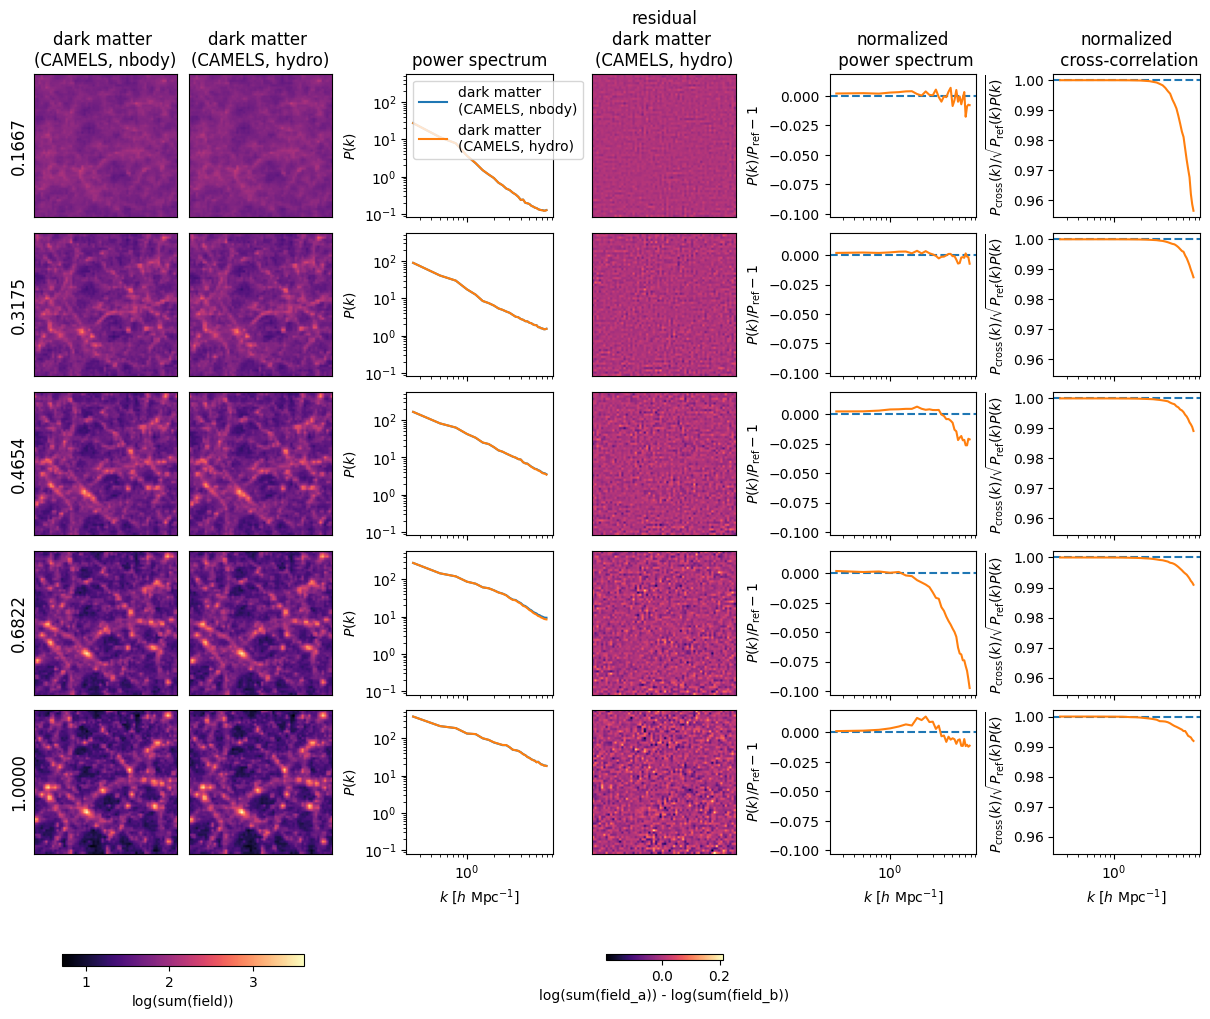

In [10]:
plotting.compare_particle_evolution(
    mesh_shape,
    scales,
    jnp.stack([n_dm_poss, h_dm_poss], axis=0),
    include_pk=True,
    include_reference=True,
    # values
    shared_colorbar=True,
    # cosmetics
    title=None,
    col_titles=["dark matter \n(CAMELS, nbody)", "dark matter \n(CAMELS, hydro)"],
)

100%|██████████| 5/5 [00:06<00:00,  1.26s/it]


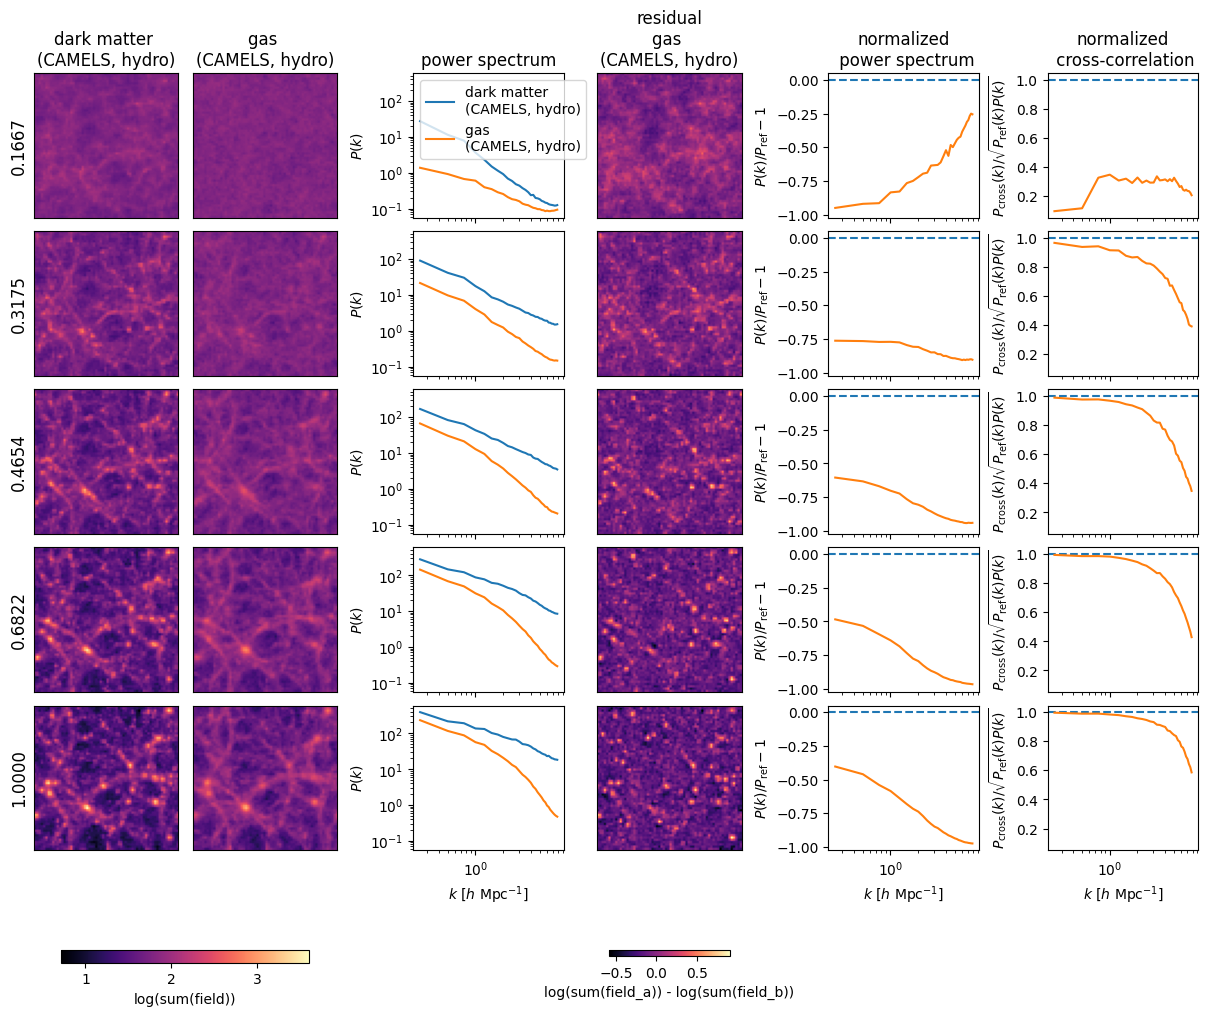

In [11]:
plotting.compare_particle_evolution(
    mesh_shape,
    scales,
    jnp.stack([h_dm_poss, h_gas_poss], axis=0),
    include_pk=True,
    include_reference=True,
    # values
    shared_colorbar=True,
    # cosmetics
    title=None,
    col_titles=["dark matter \n(CAMELS, hydro)", "gas \n(CAMELS, hydro)"],
)

## gravity only

### PM

In [12]:
pm_ode = pm.make_ode_fn_diffrax(cosmo, mesh_shape)

res = diffeqsolve(
        terms=ODETerm(pm_ode),
        solver=LeapfrogMidpoint(),
        t0=scales[0],
        t1=scales[-1],
        dt0=0.01,
        y0=jnp.stack([h_dm_poss[0], h_dm_vels[0]]),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)
res = res.ys
res = jnp.transpose(res, (1,0,2,3))

pm_dm_poss, pm_dm_vels = res

100%|██████████| 5/5 [00:06<00:00,  1.25s/it]


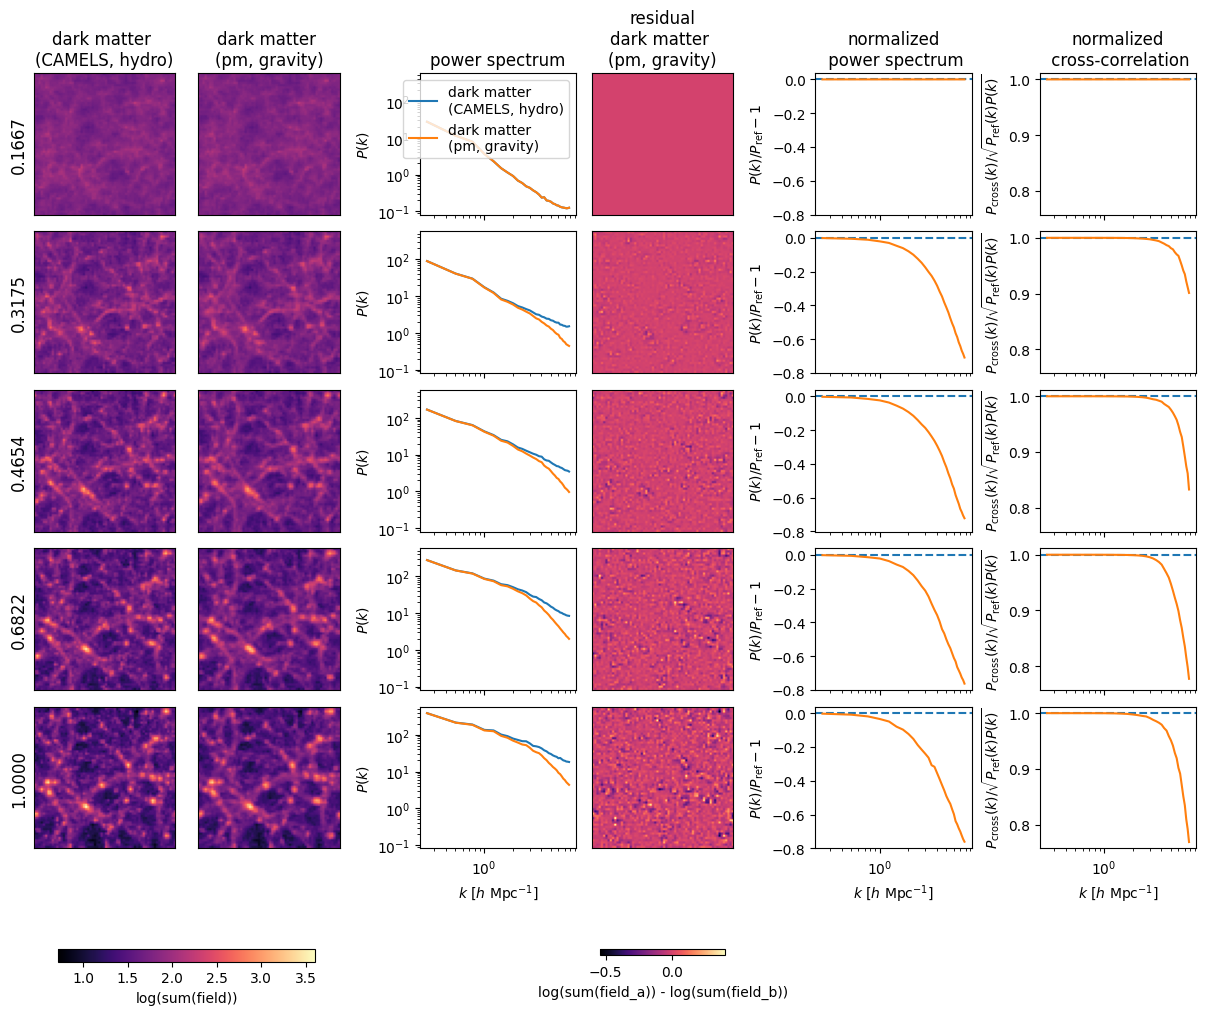

In [13]:
plotting.compare_particle_evolution(
    mesh_shape,
    scales,
    jnp.stack([h_dm_poss, pm_dm_poss], axis=0),
    include_pk=True,
    include_reference=True,
    # values
    shared_colorbar=True,
    # cosmetics
    title=None,
    col_titles=["dark matter \n(CAMELS, hydro)", "dark matter \n(pm, gravity)"],
)

### HPM

In [14]:
hpm_ode = hpm.get_hpm_network_ode_fn(None, mesh_shape, h_cosmo, gravity_only=True, integrator_type="diffrax")

res = diffeqsolve(
        terms=ODETerm(hpm_ode),
        solver=LeapfrogMidpoint(),
        t0=scales[0],
        t1=scales[-1],
        dt0=0.01,
        y0=(h_dm_poss[0], h_dm_vels[0], h_gas_poss[0], h_gas_vels[0]),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)
res = res.ys

hpm_dm_poss, hpm_dm_vels, hpm_gas_poss, hpm_gas_vels = res

100%|██████████| 5/5 [00:06<00:00,  1.24s/it]


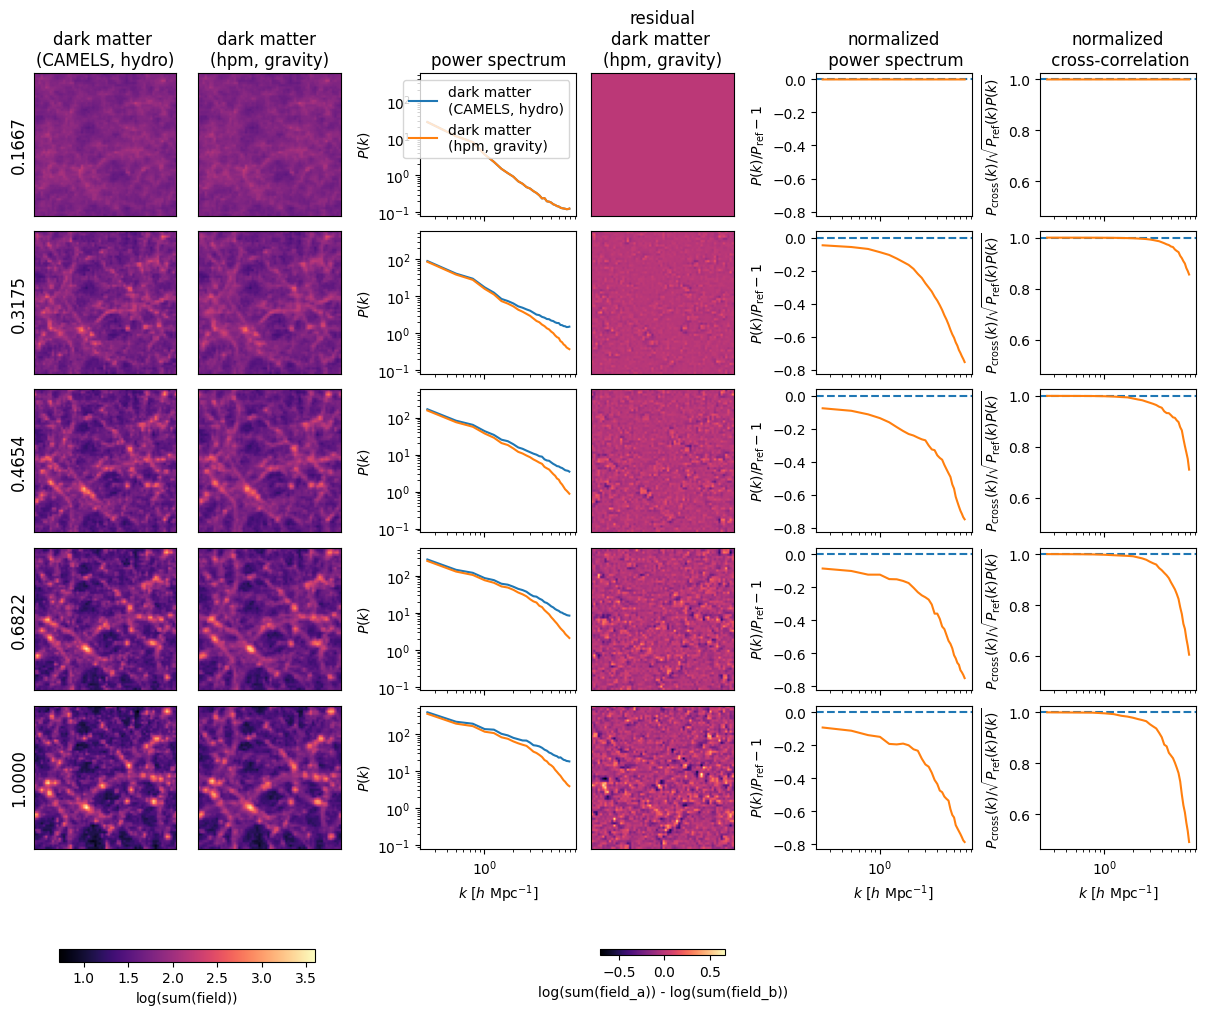

In [15]:
plotting.compare_particle_evolution(
    mesh_shape,
    scales,
    jnp.stack([h_dm_poss, hpm_dm_poss], axis=0),
    include_pk=True,
    include_reference=True,
    # values
    shared_colorbar=True,
    # cosmetics
    title=None,
    col_titles=["dark matter \n(CAMELS, hydro)", "dark matter \n(hpm, gravity)"],
)

100%|██████████| 5/5 [00:06<00:00,  1.24s/it]


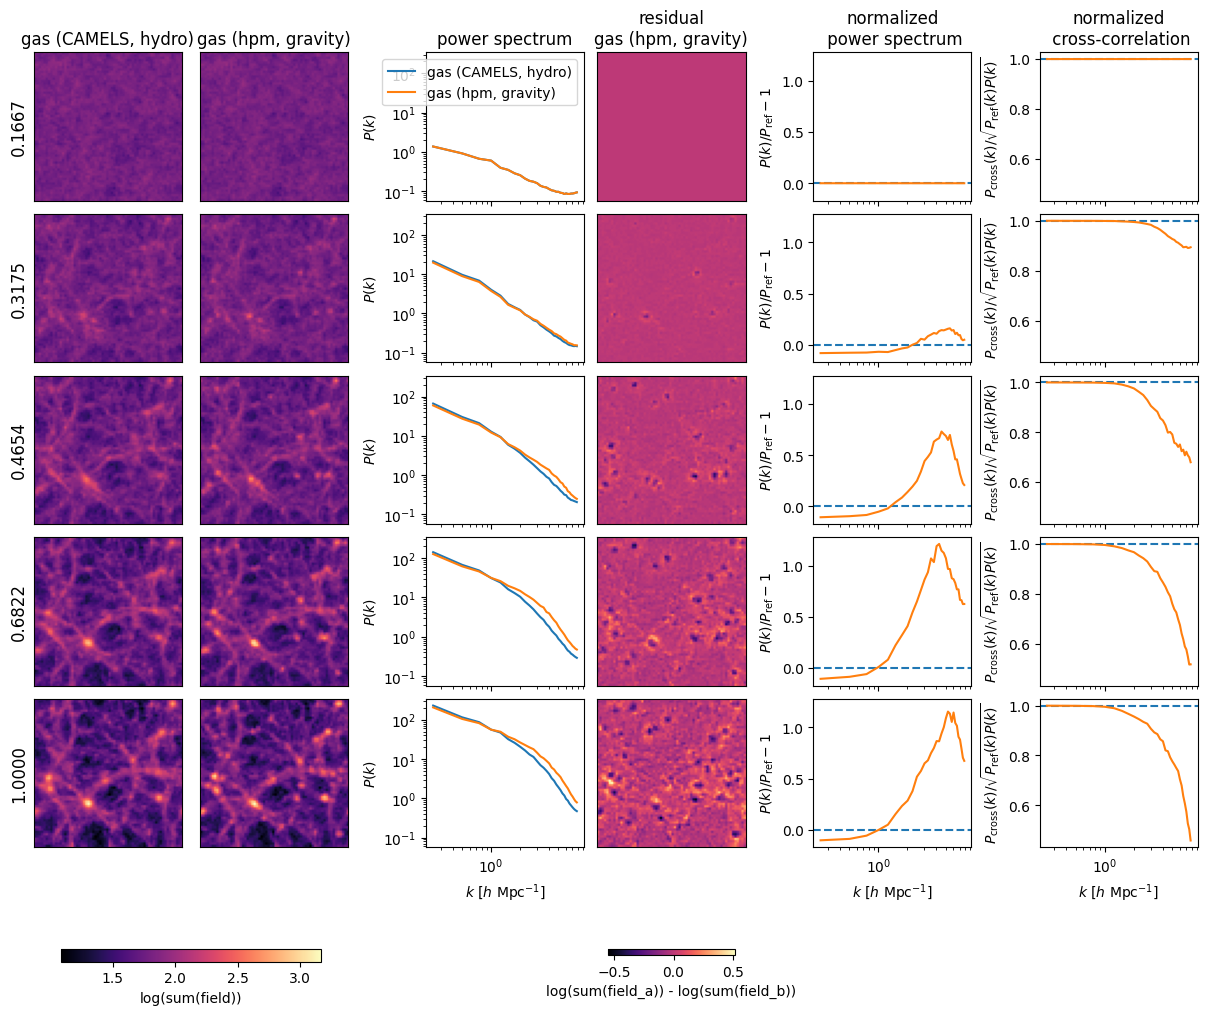

In [16]:
plotting.compare_particle_evolution(
    mesh_shape,
    scales,
    jnp.stack([h_gas_poss, hpm_gas_poss], axis=0),
    include_pk=True,
    include_reference=True,
    # values
    shared_colorbar=True,
    # cosmetics
    title=None,
    col_titles=["gas (CAMELS, hydro)", "gas (hpm, gravity)"],
)